# Part 1.3 -- Machine Learning Analysis
## Case Study: Data Science for Supply Chain Management

Two public datasets, two models, one per dataset:

1. **DataCo Smart Supply Chain** -- classification: is an order at risk of late delivery?
   Model: **Logistic Regression**.
2. **Retail Store Inventory Forecasting** -- regression: predict `Units Sold`.
   Model: **Random Forest Regressor**.

Neither model repeats my earlier assignments (kNN, Decision Tree, KNN regression,
collaborative filtering). Both are public, partly synthetic datasets, so results here are a
case-study demonstration of method, not a production recommendation for a real retailer.

Place `DataCoSupplyChainDataset.csv` and `retail_store_inventory.csv` in the same folder as
this notebook before running it.

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix,
                              mean_absolute_error, mean_squared_error, r2_score)

plt.rcParams['figure.figsize'] = (6, 4)
sns.set_style('whitegrid')

RANDOM_STATE = 42

## 2. DataCo Data Preparation

**Business question:** can we identify orders at risk of late delivery, using only information
available when the order is placed? Target: `Late_delivery_risk` (1 = late, 0 = not late).

In [2]:
dataco = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin1')
print("Shape:", dataco.shape)
print("Duplicate rows:", dataco.duplicated().sum())
dataco.isnull().sum().sort_values(ascending=False).head(5)

Shape: (180519, 53)


Duplicate rows: 0


Product Description              180519
Order Zipcode                    155679
Customer Lname                        8
Customer Zipcode                      3
Days for shipment (scheduled)         0
dtype: int64

`Product Description` and `Order Zipcode` are mostly missing, but neither is used below. No duplicates.

In [3]:
dataco['Delivery Status'].value_counts()

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

**Filtering, not a predictor.** `Delivery Status` is used here only to identify and
remove the 7,754 `Shipping canceled` rows -- it is never used as a model input. Cancelled
orders were excluded because late-delivery risk is only meaningful for orders that entered the
delivery process. So the model below should be read as predicting late delivery **among
orders that proceeded to fulfilment**, not predicting whether an order is cancelled.

In [4]:
dataco_clean = dataco[dataco['Delivery Status'] != 'Shipping canceled'].copy()
print("Rows before:", len(dataco), " Rows after:", len(dataco_clean))
dataco_clean['Late_delivery_risk'].value_counts(normalize=True)

Rows before: 180519  Rows after: 172765


Late_delivery_risk
1    0.5729
0    0.4271
Name: proportion, dtype: float64

**Leakage check.** The principle: only use information that would realistically be
available at the moment the order is placed.

In [5]:
leakage_check = pd.DataFrame([
    ['Late_delivery_risk',            'Exclude', 'This is the target'],
    ['Delivery Status',               'Exclude', 'Post-outcome label (used only for filtering above, not as a predictor)'],
    ['Days for shipping (real)',      'Exclude', 'Actual transit time -- only known after delivery'],
    ['shipping date (DateOrders)',    'Exclude', 'Only known once shipping has started'],
    ['order date (DateOrders)',       'Keep',    'Order timestamp -- available when the order is placed'],
    ['Shipping Mode',                 'Keep',    'Chosen by the customer/business at order time'],
    ['Days for shipment (scheduled)', 'Exclude', 'Maps 1-to-1 onto Shipping Mode (checked below) -- would duplicate that signal'],
], columns=['Variable', 'Decision', 'Reason'])
leakage_check

,Variable,Decision,Reason
0,Late_delivery_risk,Exclude,This is the target
1,Delivery Status,Exclude,Post-outcome label (used only for filtering ab...
2,Days for shipping (real),Exclude,Actual transit time -- only known after delivery
3,shipping date (DateOrders),Exclude,Only known once shipping has started
4,order date (DateOrders),Keep,Order timestamp -- available when the order is...
5,Shipping Mode,Keep,Chosen by the customer/business at order time
6,Days for shipment (scheduled),Exclude,Maps 1-to-1 onto Shipping Mode (checked below)...


In [6]:
pd.crosstab(dataco_clean['Shipping Mode'], dataco_clean['Days for shipment (scheduled)'])

Days for shipment (scheduled),0,1,2,4
Shipping Mode,,,,
First Class,0,26513,0,0
Same Day,9293,0,0,0
Second Class,0,0,33806,0
Standard Class,0,0,0,103153


**Features:** Categorical -- `Shipping Mode`, `Customer Segment`, `Market`, `Order
Region`. Numeric -- `Order Item Quantity`, `Order Item Product Price`, `Order Item Discount
Rate`, `Order Item Total`, `order_month` (from `order date`).

In [7]:
dataco_clean['order_dt'] = pd.to_datetime(dataco_clean['order date (DateOrders)'])
dataco_clean['order_month'] = dataco_clean['order_dt'].dt.month

cat_cols = ['Shipping Mode', 'Customer Segment', 'Market', 'Order Region']
num_cols = ['Order Item Quantity', 'Order Item Product Price', 'Order Item Discount Rate',
            'Order Item Total', 'order_month']

X = dataco_clean[cat_cols + num_cols]
y = dataco_clean['Late_delivery_risk']
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

Train size: 138212  Test size: 34553


In [8]:
# Logistic Regression is sensitive to feature scale, so scale numeric columns only
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

## 3. DataCo Baseline -- Logistic Regression (threshold = 0.50)

In [9]:
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)
proba_test = logreg.predict_proba(X_test_scaled)[:, 1]

pred_base = (proba_test >= 0.5).astype(int)
acc_base = accuracy_score(y_test, pred_base)
prec_base = precision_score(y_test, pred_base)
rec_base = recall_score(y_test, pred_base)
f1_base = f1_score(y_test, pred_base)
auc_base = roc_auc_score(y_test, proba_test)

print(f"threshold=0.50: Accuracy={acc_base:.3f} Precision={prec_base:.3f} "
      f"Recall={rec_base:.3f} F1={f1_base:.3f} ROC-AUC={auc_base:.3f}")

threshold=0.50: Accuracy=0.698 Precision=0.885 Recall=0.543 F1=0.673 ROC-AUC=0.745


## 4. DataCo -- Changing the Operating Threshold

This is the **same trained model** -- only the cutoff for calling a prediction "late" changes.
0.50 isn't a rule, just the default. The threshold is selected using a validation split carved
out of the *training* data only, with the scaler re-fit on that training portion alone (not on
the validation rows) to avoid leaking validation information into preprocessing. The test set
stays unseen until the one-time check below.

In [10]:
X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train)

# Fit a fresh scaler on X_tr2 ONLY, so the validation subset never influences the
# scaler's mean/std -- avoids leaking validation information into preprocessing.
scaler_val = StandardScaler()
X_tr2_scaled = X_tr2.copy()
X_val_scaled = X_val.copy()
X_tr2_scaled[num_cols] = scaler_val.fit_transform(X_tr2[num_cols])
X_val_scaled[num_cols] = scaler_val.transform(X_val[num_cols])

model_val = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model_val.fit(X_tr2_scaled, y_tr2)
proba_val = model_val.predict_proba(X_val_scaled)[:, 1]

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
sweep = pd.DataFrame({
    'threshold': thresholds,
    'precision': [precision_score(y_val, (proba_val >= t).astype(int)) for t in thresholds],
    'recall':    [recall_score(y_val, (proba_val >= t).astype(int)) for t in thresholds],
    'f1':        [f1_score(y_val, (proba_val >= t).astype(int)) for t in thresholds],
})
sweep

,threshold,precision,recall,f1
0,0.30,0.572912,1.000000,0.728473
1,0.35,0.574090,0.998358,0.728987
2,0.40,0.657574,0.770222,0.709454
3,0.45,0.834584,0.583002,0.686468
4,0.50,0.886849,0.539938,0.671219
5,0.55,0.887527,0.539622,0.671169
6,0.60,0.887527,0.539622,0.671169


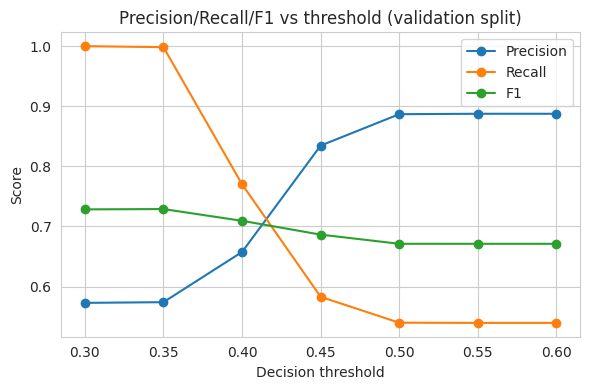

In [11]:
plt.figure(figsize=(6, 4))
plt.plot(sweep['threshold'], sweep['precision'], marker='o', label='Precision')
plt.plot(sweep['threshold'], sweep['recall'], marker='o', label='Recall')
plt.plot(sweep['threshold'], sweep['f1'], marker='o', label='F1')
plt.xlabel('Decision threshold')
plt.ylabel('Score')
plt.title('Precision/Recall/F1 vs threshold (validation split)')
plt.legend()
plt.tight_layout()
plt.show()

Although thresholds of 0.30-0.35 produce slightly higher validation F1, they flag almost
every order as "late" (recall near 100%, precision only ~0.57) -- not a useful signal, since it
stops distinguishing risky orders from the rest. **0.40 provides a more balanced trade-off**:
it gives up a little F1 compared to 0.30-0.35, but substantially increases recall over 0.50
while retaining meaningfully higher precision than the lower thresholds. Applying it to the
test set once, as a final check, not as part of the search.

In [12]:
pred_improved = (proba_test >= 0.40).astype(int)
acc_thr = accuracy_score(y_test, pred_improved)
prec_thr = precision_score(y_test, pred_improved)
rec_thr = recall_score(y_test, pred_improved)
f1_thr = f1_score(y_test, pred_improved)
auc_thr = auc_base  # same model/probabilities -- ROC-AUC does not depend on the threshold

print(f"threshold=0.40: Accuracy={acc_thr:.3f} Precision={prec_thr:.3f} "
      f"Recall={rec_thr:.3f} F1={f1_thr:.3f} ROC-AUC={auc_thr:.3f}")

threshold=0.40: Accuracy=0.641 Precision=0.658 Recall=0.778 F1=0.713 ROC-AUC=0.745


## 5. DataCo Evaluation

In [13]:
dataco_compare = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    'Threshold 0.50': [acc_base, prec_base, rec_base, f1_base, auc_base],
    'Threshold 0.40': [acc_thr, prec_thr, rec_thr, f1_thr, auc_thr],
}).round(3)
dataco_compare

,Metric,Threshold 0.50,Threshold 0.40
0,Accuracy,0.698,0.641
1,Precision,0.885,0.658
2,Recall,0.543,0.778
3,F1-score,0.673,0.713
4,ROC-AUC,0.745,0.745


This is a **change in operating threshold, not a universally "better" model** -- ROC-AUC
is identical (0.745) because it's the same trained model either way. Moving to 0.40 raises
recall (0.543 -> 0.778) and F1 (0.673 -> 0.713), but lowers precision and accuracy. Which
threshold is preferable depends on the cost of the two error types: **if missing a genuinely
late order is considered more costly than generating additional alerts, the 0.40 threshold
could be considered** for a risk-screening use case -- this is a trade-off to weigh, not a
deployment instruction, and this remains a public-dataset case study rather than a validated
recommendation for a real retailer.

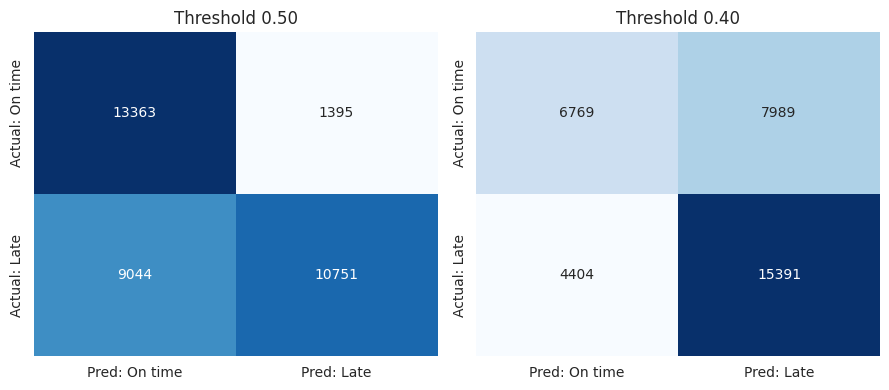

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, pred, title in [(axes[0], pred_base, 'Threshold 0.50'),
                          (axes[1], pred_improved, 'Threshold 0.40')]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Pred: On time', 'Pred: Late'],
                yticklabels=['Actual: On time', 'Actual: Late'], ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()

Fewer late orders are missed (bottom-left cell) at threshold 0.40, at the cost of more false alarms (top-right cell).

**Shipping Mode.** Checking sample sizes before treating the rate differences as a finding.

In [15]:
shipping_summary = dataco_clean.groupby('Shipping Mode')['Late_delivery_risk'].agg(
    Number_of_orders='count', Number_of_late_orders='sum').reset_index()
shipping_summary['Late_delivery_rate'] = (shipping_summary['Number_of_late_orders'] /
                                           shipping_summary['Number_of_orders']).round(3)
shipping_summary = shipping_summary.sort_values('Late_delivery_rate')
shipping_summary

,Shipping Mode,Number_of_orders,Number_of_late_orders,Late_delivery_rate
3,Standard Class,103153,41023,0.398
1,Same Day,9293,4454,0.479
2,Second Class,33806,26987,0.798
0,First Class,26513,26513,1.000


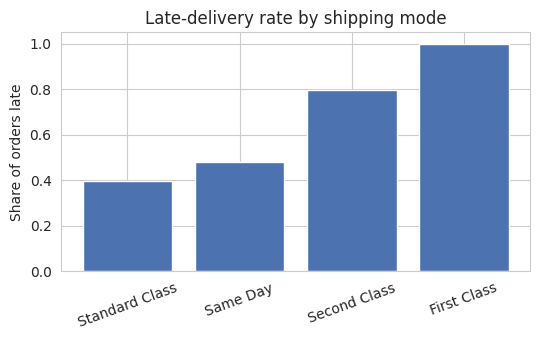

In [16]:
plt.figure(figsize=(5.5, 3.5))
plt.bar(shipping_summary['Shipping Mode'], shipping_summary['Late_delivery_rate'], color='#4C72B0')
plt.ylabel('Share of orders late')
plt.title('Late-delivery rate by shipping mode')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Shipping Mode shows a strong relationship with late delivery: Standard Class ~39.8%,
Same Day ~47.9%, Second Class ~79.8%, First Class 100% (n=26,513). The First Class sample is
large, so this isn't a small-N fluke, but a 100% rate is still an unusual pattern -- it may
reflect characteristics of how this public dataset was constructed and should not be directly
generalised to a real retailer. I'm not claiming Shipping Mode *causes* late delivery, only
that it's strongly associated with it in this dataset.

## 6. Retail Data Preparation

**Business question:** can we predict `Units Sold` from store, product and pricing
information?

In [17]:
retail = pd.read_csv('retail_store_inventory.csv')
print("Shape:", retail.shape)
print("Missing values:", retail.isnull().sum().sum())
print("Duplicate rows:", retail.duplicated().sum())

Shape: (73100, 15)
Missing values: 0
Duplicate rows: 0


No missing values, no duplicates.

In [18]:
retail[['Units Sold', 'Demand Forecast']].corr()

,Units Sold,Demand Forecast
Units Sold,1.000000,0.996853
Demand Forecast,0.996853,1.000000


**`Demand Forecast` leakage check.** Its near-perfect correlation (0.997) with `Units
Sold` suggests it contains information too closely related to the target, creating a risk of
target leakage -- it was therefore excluded. `Units Sold` is the target.

**Features:** Categorical -- `Category`, `Region`, `Weather Condition`, `Seasonality`.
Numeric -- `Inventory Level`, `Units Ordered`, `Price`, `Discount`, `Holiday/Promotion`,
`Competitor Pricing`. `Store ID`/`Product ID` left out (only 5 stores / 20 products --
`Category`/`Region` already cover most of that). No scaling needed for Random Forest.

In [19]:
cat_cols_r = ['Category', 'Region', 'Weather Condition', 'Seasonality']
num_cols_r = ['Inventory Level', 'Units Ordered', 'Price', 'Discount',
              'Holiday/Promotion', 'Competitor Pricing']

X_r = retail[cat_cols_r + num_cols_r]
y_r = retail['Units Sold']
X_r = pd.get_dummies(X_r, columns=cat_cols_r, drop_first=True)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r, y_r, test_size=0.2, random_state=RANDOM_STATE)
print("Train size:", X_train_r.shape[0], " Test size:", X_test_r.shape[0])

Train size: 58480  Test size: 14620


## 7. Retail Baseline -- Random Forest Regressor

In [20]:
rf_base = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
rf_base.fit(X_train_r, y_train_r)
pred_base_r = rf_base.predict(X_test_r)

mae_base = mean_absolute_error(y_test_r, pred_base_r)
rmse_base = mean_squared_error(y_test_r, pred_base_r) ** 0.5
r2_base = r2_score(y_test_r, pred_base_r)
print(f"MAE={mae_base:.2f} RMSE={rmse_base:.2f} R2={r2_base:.3f}")

MAE=69.05 RMSE=88.31 R2=0.341


## 8. Retail -- Testing for Improvements

Tried a small hyperparameter comparison and two simple engineered features
(`price_diff` = Price - Competitor Pricing, `dayofweek`), both checked on a validation split
carved from training data only.

In [21]:
Xr_tr2, Xr_val, yr_tr2, yr_val = train_test_split(
    X_train_r, y_train_r, test_size=0.2, random_state=RANDOM_STATE)

configs = {
    'baseline (n=200, depth=10)': dict(n_estimators=200, max_depth=10),
    'max_depth=6': dict(n_estimators=200, max_depth=6),
    'max_depth=15': dict(n_estimators=200, max_depth=15),
    'min_samples_leaf=5': dict(n_estimators=200, max_depth=10, min_samples_leaf=5),
}
for label, params in configs.items():
    m = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **params)
    m.fit(Xr_tr2, yr_tr2)
    pred_val = m.predict(Xr_val)
    print(f"{label}: R2={r2_score(yr_val, pred_val):.4f}")

baseline (n=200, depth=10): R2=0.3346


max_depth=6: R2=0.3365


max_depth=15: R2=0.3281


min_samples_leaf=5: R2=0.3347


In [22]:
retail['dt'] = pd.to_datetime(retail['Date'])
retail['dayofweek'] = retail['dt'].dt.dayofweek
retail['price_diff'] = retail['Price'] - retail['Competitor Pricing']

num_cols_ext = num_cols_r + ['dayofweek', 'price_diff']
X_r_ext = pd.get_dummies(retail[cat_cols_r + num_cols_ext], columns=cat_cols_r, drop_first=True)
Xre_train, _, yre_train, _ = train_test_split(X_r_ext, y_r, test_size=0.2, random_state=RANDOM_STATE)
Xre_tr2, Xre_val, yre_tr2, yre_val = train_test_split(Xre_train, yre_train, test_size=0.2, random_state=RANDOM_STATE)

m_ext = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
m_ext.fit(Xre_tr2, yre_tr2)
pred_ext_val = m_ext.predict(Xre_val)
print(f"With price_diff + dayofweek: R2={r2_score(yre_val, pred_ext_val):.4f}  (baseline: 0.3346)")

With price_diff + dayofweek: R2=0.3351  (baseline: 0.3346)


The best alternative increased validation R\u00b2 only from 0.3346 to 0.3365, a very
small improvement that did not justify adding model complexity. The baseline Random Forest was
therefore retained as the final model. This is consistent with the feature importance result
below, where one variable dominates and the others contribute little.

In [23]:
mae_imp_r, rmse_imp_r, r2_imp_r = mae_base, rmse_base, r2_base  # improved = baseline; nothing tested helped
pred_improved_r = pred_base_r

## 9. Retail Evaluation

MAE (average error in units), RMSE (penalises large errors more -- relevant since a big miss
means a stockout or excess stock), R\u00b2 (variance explained). At R\u00b2 = 0.341, the
model captures roughly a third of the variation in daily sales -- a useful starting signal, not
a precise forecast.

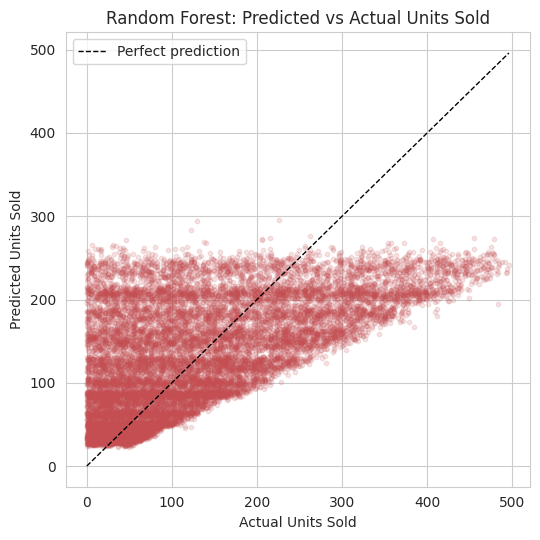

In [24]:
plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_test_r, pred_base_r, alpha=0.15, s=10, color='#C44E52')
lims = [0, max(y_test_r.max(), pred_base_r.max())]
plt.plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
plt.xlabel('Actual Units Sold')
plt.ylabel('Predicted Units Sold')
plt.title('Random Forest: Predicted vs Actual Units Sold')
plt.legend()
plt.tight_layout()
plt.show()

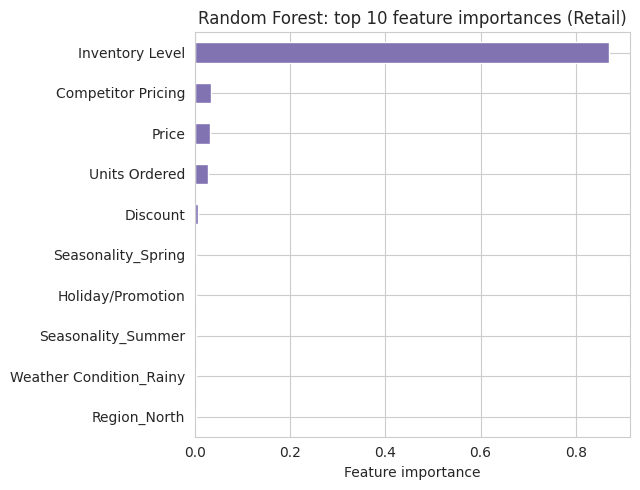

Inventory Level            0.870566
Competitor Pricing         0.033095
Price                      0.032082
Units Ordered              0.028115
Discount                   0.007372
Seasonality_Spring         0.002326
Holiday/Promotion          0.002282
Seasonality_Summer         0.002187
Weather Condition_Rainy    0.002167
Region_North               0.002130
dtype: float64

In [25]:
importances = pd.Series(rf_base.feature_importances_, index=X_train_r.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(6.5, 5))
importances.sort_values().plot(kind='barh', color='#8172B2')
plt.xlabel('Feature importance')
plt.title('Random Forest: top 10 feature importances (Retail)')
plt.tight_layout()
plt.show()
importances

`Inventory Level` was the dominant feature in the Random Forest model, with an
importance of approximately 0.87. The remaining variables contributed substantially less to
the model's predictions. Feature importance reflects what the trained model relied on most --
it does not establish that inventory level causes sales.

## 10. Baseline vs Threshold-Adjusted / Tuned Results

In [26]:
rows = []
for metric, base_val, thr_val in [
    ('Accuracy', acc_base, acc_thr), ('Precision', prec_base, prec_thr),
    ('Recall', rec_base, rec_thr), ('F1-score', f1_base, f1_thr),
    ('ROC-AUC', auc_base, auc_thr),
]:
    rows.append({'Dataset': 'DataCo', 'Model': 'Logistic Regression', 'Version': 'Threshold 0.50', 'Metric': metric, 'Value': round(base_val, 3)})
    rows.append({'Dataset': 'DataCo', 'Model': 'Logistic Regression', 'Version': 'Threshold 0.40', 'Metric': metric, 'Value': round(thr_val, 3)})

for metric, base_val, imp_val in [
    ('MAE', mae_base, mae_imp_r), ('RMSE', rmse_base, rmse_imp_r), ('R2', r2_base, r2_imp_r),
]:
    rows.append({'Dataset': 'Retail', 'Model': 'Random Forest', 'Version': 'Baseline', 'Metric': metric, 'Value': round(base_val, 3)})
    rows.append({'Dataset': 'Retail', 'Model': 'Random Forest', 'Version': 'Tuned (retained baseline)', 'Metric': metric, 'Value': round(imp_val, 3)})

results_df = pd.DataFrame(rows)
results_df.to_csv('model_results.csv', index=False)
results_df

,Dataset,Model,Version,Metric,Value
0,DataCo,Logistic Regression,Threshold 0.50,Accuracy,0.698
1,DataCo,Logistic Regression,Threshold 0.40,Accuracy,0.641
2,DataCo,Logistic Regression,Threshold 0.50,Precision,0.885
3,DataCo,Logistic Regression,Threshold 0.40,Precision,0.658
4,DataCo,Logistic Regression,Threshold 0.50,Recall,0.543
5,DataCo,Logistic Regression,Threshold 0.40,Recall,0.778
6,DataCo,Logistic Regression,Threshold 0.50,F1-score,0.673
7,DataCo,Logistic Regression,Threshold 0.40,F1-score,0.713
8,DataCo,Logistic Regression,Threshold 0.50,ROC-AUC,0.745
9,DataCo,Logistic Regression,Threshold 0.40,ROC-AUC,0.745


## 11. Key Findings

1. The DataCo model's threshold can be adjusted to prioritise recall, increasing recall from
   54.3% to 77.8% and F1 from 67.3% to 71.3%, at the cost of lower precision and accuracy.
   ROC-AUC is unchanged (0.745) since it's the same underlying model.

2. Shipping Mode is strongly associated with late-delivery risk in DataCo, although the
   unusual 100% First Class rate (n=26,513) should be interpreted cautiously rather than taken
   as a realistic carrier statistic.

3. `Demand Forecast` was excluded from the Retail model because its 0.997 correlation with
   `Units Sold` indicated a risk of target leakage.

4. `Inventory Level` was the dominant feature in the Retail Random Forest model, with
   approximately 0.87 feature importance, while overall model performance remained moderate
   (R\u00b2 = 0.341). Hyperparameter tuning and simple feature engineering did not meaningfully
   change this.

5. The two datasets provide complementary perspectives -- DataCo on fulfilment/delivery risk,
   Retail Inventory on demand/inventory behaviour -- though in both cases predictive power
   turned out to be concentrated in a single dominant variable rather than a broad mix of
   factors.

## 12. Business Implications

1. **Finding:** threshold 0.40 substantially raises recall at a real cost to precision.
   **Meaning:** neither threshold is universally "correct" -- it depends on whether missed
   late orders or extra alerts are more costly.
   **Possible use:** the model could support a risk-screening step (flagging orders for
   review), with the threshold chosen to match that trade-off, rather than as an automated
   final decision.

2. **Finding:** Shipping Mode shows the strongest relationship with late delivery.
   **Meaning:** delivery performance appears to differ substantially by shipping option in
   this dataset.
   **Possible use:** monitoring delivery performance by shipping mode is a reasonable
   starting point for further investigation in a real operation.

3. **Finding:** Inventory Level dominates the Retail model, and other variables (price,
   promotion, weather) added little.
   **Meaning:** the usual demand-shaping levers aren't well represented in this dataset.
   **Possible use:** paying attention to inventory levels is the most defensible takeaway from
   this specific model; richer operational data would be needed before trusting
   pricing/promotion-driven forecasts.

## 13. Limitations

- DataCo is a US-focused public dataset; patterns like the Shipping Mode effect may not
  transfer to a different retailer or region.
- The Retail dataset appears synthetic -- no combination of tuning or simple feature
  engineering could extract more signal than `Inventory Level` alone provides.
- Leakage decisions reflect my own judgement about what's realistically known at order time,
  not a verified real-world order-processing sequence.
- Threshold and hyperparameter choices were validated on a single held-out split, not
  cross-validated, so exact values could shift slightly with a different split.
- Both datasets cover a fixed historical period and limited scope, so findings should not be
  generalised directly to a real business such as Woolworths without retraining on real data.

## 14. Conclusion

This analysis shows that model performance depends on the business objective, not just a
single accuracy figure: the DataCo threshold decision is a precision/recall trade-off, not a
one-size-fits-all improvement. Retail Inventory provides useful but limited predictive
information, dominated by a single feature (Inventory Level) that the Random Forest could not
meaningfully improve on through tuning. Together, the two datasets offer complementary
supply-chain perspectives -- fulfilment risk and demand/inventory behaviour -- but both are
public, partly synthetic datasets, so these findings describe what the data shows rather than
conclusions that should be generalised directly to Woolworths or any specific retailer.